# DiSC Stability Analysis Notebook

This Jupyter notebook provides a **comprehensive analysis** of the Digital Skull Clamp (DiSC) stability criteria. It includes:
1. Mathematical model and key formulas
2. Python functions for geometry, stability index, classification, and visualization
3. Example runs over multiple configurations
4. Sensitivity analysis and plots

Use the toolbar to run each cell in order.

## Key Formulas

**Lever arm** per pin:

$$
r_i = R \sin\!\left(\frac{\theta_i}{2}\right)
$$

**Slip torque** per pin:

$$
\tau_i = \mu F_i r_i
$$

**Reference torque** (ideal symmetric 120° layout):

$$
\tau_{\mathrm{ref}} = \mu F_{\mathrm{ref}} R \sin\!(60^\circ)
$$

**Stability index**:

$$
S_i = \frac{\tau_i}{\tau_{\mathrm{ref}}}
$$

**Classification**  
- $S_i > 1.2$: **stable**  
- $0.8 \le S_i \le 1.2$: **marginal**  
- $S_i < 0.8$: **critical**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def geometry_from_markers(skull_center, pin_markers):
    """
    Compute skull radius R, pin separation angles θ_i, and lever-arms r_i.
    """
    vs = [np.array(p) - np.array(skull_center) for p in pin_markers]
    norms = [np.linalg.norm(v) for v in vs]
    R_est = float(np.mean(norms))
    thetas = []
    for i in range(3):
        j = (i + 1) % 3
        cos_theta = np.dot(vs[i], vs[j]) / (norms[i] * norms[j])
        theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))
        thetas.append(np.rad2deg(theta))
    return R_est, thetas, norms

def compute_stability_index(R, mu, forces, thetas_deg):
    """
    Compute per-pin torque τ_i and normalized stability S_i.
    """
    thetas = np.deg2rad(thetas_deg)
    lever_arms = R * np.sin(thetas / 2)
    torques = mu * np.array(forces) * lever_arms
    theta_ref = np.deg2rad(120)
    F_ref = np.mean(forces)
    r_ref = R * np.sin(theta_ref / 2)
    tau_ref = mu * F_ref * r_ref
    S = torques / tau_ref
    return torques, S

def classify_stability(S, thresholds=(0.8, 1.2)):
    """
    Label each S_i as 'stable', 'marginal', or 'critical'.
    """
    labels = []
    for s in S:
        if s > thresholds[1]:
            labels.append('stable')
        elif s >= thresholds[0]:
            labels.append('marginal')
        else:
            labels.append('critical')
    return labels

def visualize_stability(R, thetas_deg, S, thresholds=(0.8, 1.2)):
    """
    Plot pin positions on a circle of radius R and a bar chart of stability indices.
    """
    acc = 0.0
    angles = [0.0]
    for theta in thetas_deg[:-1]:
        acc += theta
        angles.append(acc)
    angles_rad = np.deg2rad(angles)
    xs = R * np.cos(angles_rad)
    ys = R * np.sin(angles_rad)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    circle = plt.Circle((0, 0), R, fill=False)
    ax1.add_artist(circle)
    ax1.scatter(xs, ys)
    for i, (x, y) in enumerate(zip(xs, ys), start=1):
        ax1.text(x, y, str(i))
    ax1.set_aspect('equal')
    ax1.set_title('Pin positions (top view)')
    ax2.bar(np.arange(1, len(S) + 1), S)
    ax2.axhline(thresholds[0], linestyle='--')
    ax2.axhline(thresholds[1], linestyle='--')
    ax2.set_xlabel('Pin')
    ax2.set_ylabel('Stability index S_i')
    ax2.set_title('Stability index per pin')
    plt.tight_layout()


## Symmetric (120°/120°/120°, 100 N)
Pin 1: S=1.00 → marginal
Pin 2: S=1.00 → marginal
Pin 3: S=1.00 → marginal
## Low Force (120°/120°/120°, 60 N)
Pin 1: S=1.00 → marginal
Pin 2: S=1.00 → marginal
Pin 3: S=1.00 → marginal
## Asymmetric (100°/130°/130°, 100 N)
Pin 1: S=0.88 → marginal
Pin 2: S=1.05 → marginal
Pin 3: S=1.05 → marginal


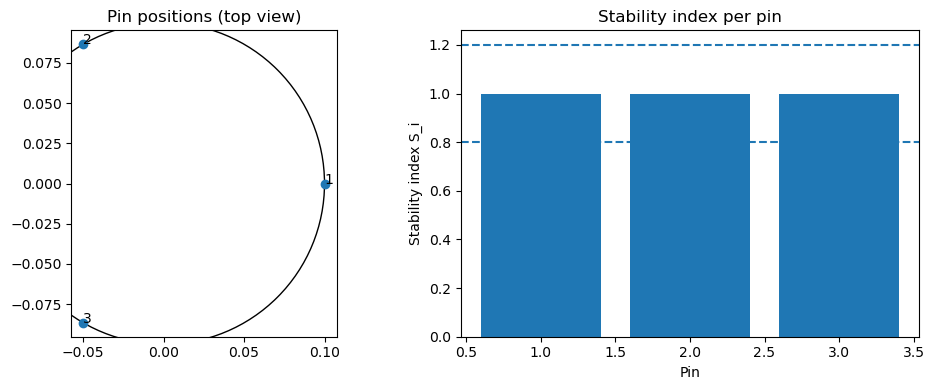

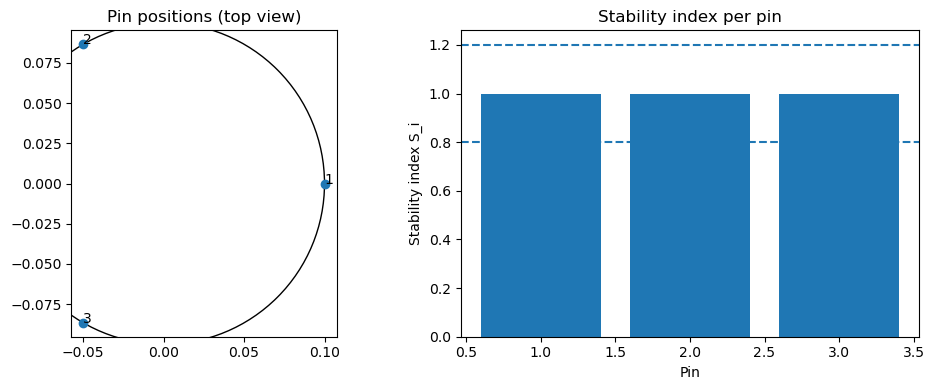

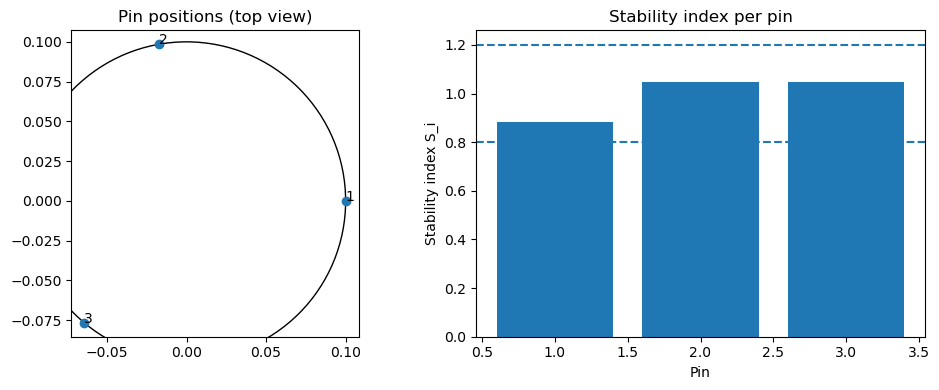

In [2]:
R = 0.1  # 100 mm
mu = 0.3
cases = {
    'Symmetric (120°/120°/120°, 100 N)': ([120, 120, 120], [100, 100, 100]),
    'Low Force (120°/120°/120°, 60 N)': ([120, 120, 120], [60, 60, 60]),
    'Asymmetric (100°/130°/130°, 100 N)': ([100, 130, 130], [100, 100, 100]),
}
for name, (thetas, forces) in cases.items():
    print(f"## {name}")
    R_est, th, r = geometry_from_markers([0, 0, 0], [[R, 0, 0], [0, R, 0], [-R, 0, 0]])
    torques, S = compute_stability_index(R_est, mu, forces, thetas)
    labels = classify_stability(S)
    for i, (s, lab) in enumerate(zip(S, labels), start=1):
        print(f"Pin {i}: S={s:.2f} → {lab}")
    visualize_stability(R_est, thetas, S)
